In [22]:
import PIL
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib as mpl
from torchvision.transforms import v2
import os
from torch.utils.data import DataLoader
from tqdm import tqdm

torch.manual_seed(17)

In [23]:
transforms = torchvision.transforms.Compose([    
    torchvision.transforms.ColorJitter(hue=.05, saturation=.05),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomRotation(25,),
    torchvision.transforms.Resize((224,224)),
    torchvision.transforms.ToTensor(), 
])

In [24]:
data_dir="C:\code\pytorch_course\plant_disease\Data\Test\Rice"
dataset = torchvision.datasets.ImageFolder(data_dir, transform=transforms)
fig = plt.figure(figsize=(25, 7))
for idx in range(3):
    image,label=dataset[idx]
    ax = fig.add_subplot(2, 20, idx+1, xticks=[], yticks=[])
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(str(label))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\code\\pytorch_course\\plant_disease\\Data\\Test\\Rice'

In [ ]:
EPOCHS = 4
BATCH_SIZE = 1

# if you want all the images in a batch to make the image-grid, 
# set GRID_SIZE = BATCH_SIZE

train_dataset = dataset
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                              shuffle=True,)

for epoch in range(EPOCHS):
    for batch_idx, (X, y) in (enumerate(tqdm(train_dataloader))):
        filepath = os.path.join(data_dir,f"{dataset.classes[y]}")
        filepath = os.path.join(filepath, f"Fake_image-{epoch}-{batch_idx}.png")
        torchvision.utils.save_image(X, filepath)

100%|██████████| 492/492 [04:08<00:00,  1.98it/s]


In [33]:
from PIL import Image
import glob
files = glob.glob('C:/code/pytorch_course/plant_disease/Test_folder/*.png')
files_reshape = list(map(lambda x: x.replace('/Labelled\\', '/Resized\\'), files))
basewidth = 300
for file, file_save in zip(files, files_reshape):
    img = Image.open(file)
    wpercent = (basewidth/float(img.size[0]))
    hsize = int((float(img.size[1])*float(wpercent)))
    img = img.resize((basewidth,hsize), Image.ANTIALIAS)
    img.save(file_save) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_13356\1204424281.py:10: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = img.resize((basewidth,hsize), Image.ANTIALIAS)


(array([11963.,  2079.,   499.,   392.,   432.,   462.,   605.,  1103.,
        31054., 41411.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

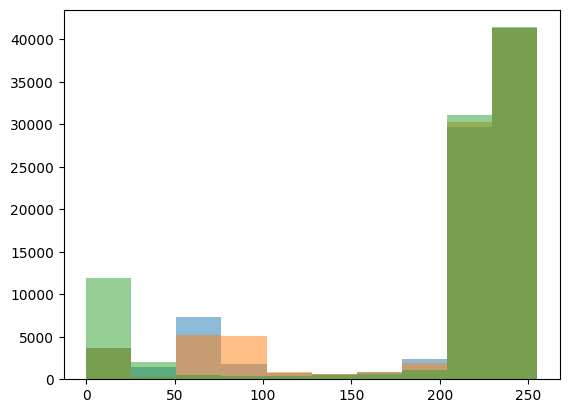

In [34]:
from skimage.morphology import binary_closing, binary_opening, erosion
files_bgremoved = list(map(lambda x: x.replace('/Labelled\\', '/BGRemoved\\'), files))
selem = np.zeros((25, 25))

ci,cj=12, 12
cr=13

# Create index arrays to z
I,J=np.meshgrid(np.arange(selem.shape[0]),np.arange(selem.shape[1]))

# calculate distance of all points to centre
dist=np.sqrt((I-ci)**2+(J-cj)**2)

# Assign value of 1 to those points where dist<cr:
selem[np.where(dist<=cr)]=1
import numpy as np
from scipy import ndimage

fig, ax = plt.subplots(20,2, figsize=(10,80))
idx = 0
for file, file_save in zip(files, files_bgremoved):
    bg_frac = 0
    thres = 220
    img = Image.open(file)
    im_arr = np.array(img)
    ax[idx, 0].imshow(im_arr)
    R = im_arr[:, :, 0]
    G = im_arr[:, :, 1]
    B = im_arr[:, :, 2]
    while bg_frac < 0.6: 
        bg_mask = ((R>thres) | (B>thres))# & (G < 100)
        bg_frac = bg_mask.sum()/len(bg_mask.flatten())
        thres -= 5
    # we use opening first since our mask is reversed (the foreground and background are reversed here)
    bg_mask = binary_closing(erosion(binary_opening(bg_mask, selem), np.ones((3, 3))), np.ones((5,5)))
    
    #Get biggest blob
    label, num_label = ndimage.label(~bg_mask)
    size = np.bincount(label.ravel())
    biggest_label = size[1:].argmax() + 1
    bg_mask = label == biggest_label
    
    im_arr[~bg_mask, 0] = 255
    im_arr[~bg_mask, 1] = 255
    im_arr[~bg_mask, 2] = 255
    
    img = Image.fromarray(im_arr)
    img.save(file_save)
    idx+=1
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(R.flatten(), alpha=0.5)
plt.hist(G.flatten(), alpha=0.5)
plt.hist(B.flatten(), alpha=0.5)

True